## Real Example application of Semi-Supervised GMM

This is the application of our code to the Gastrointestinal Lesions in Regular Colonoscopy dataset that can be found [here](https://archive.ics.uci.edu/dataset/408/gastrointestinal+lesions+in+regular+colonoscopy).

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from data.real_example.preprocessing import load_data_binary
from utils.real_example.evaluation import _em_impute, evaluate_imputers, visualize_evaluation_results, test_gmm_normality_assumptions


X, y_groundtruth, y_experts = load_data_binary(data_file='data\\real_example\\data.csv', gt_file='data\\real_example\\ground_truth.xlsx')

# 1. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
print(f"Missing percentage={np.sum(np.isnan(y_experts))/len(y_groundtruth)}")

Missing percentage=0.42105263157894735


### Reduction to 10 Dimensions

In [2]:
# 2. Apply PCA (Retaining )
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance= {pca.explained_variance_ratio_.sum()} \n")

Explained variance= 0.7341792049530251 



In [3]:
results_df = evaluate_imputers(X_pca, y_experts, y_groundtruth)
results_df.to_csv("results\\real_example\\10_d\\10d_metrics_results.csv")

# # Display a quick summary
results_df

,Accuracy,Recall_Class_1,Precision_Class_1,F1_Class_1,Pi_Diff_Class_1
Imputer,,,,,
Mode Imputer,0.763158,0.945455,0.776119,0.852459,0.071770
KNN Imputer (k=5),0.881579,0.927273,0.910714,0.918919,0.013158
Random Forest Imputer,0.815789,0.927273,0.836066,0.879310,0.078947
EM-GMM Imputer,0.763158,0.945455,0.776119,0.852459,0.157895


--- Multivariate Normality Diagnostic ---

Analyzing Cluster 0 (n=21)


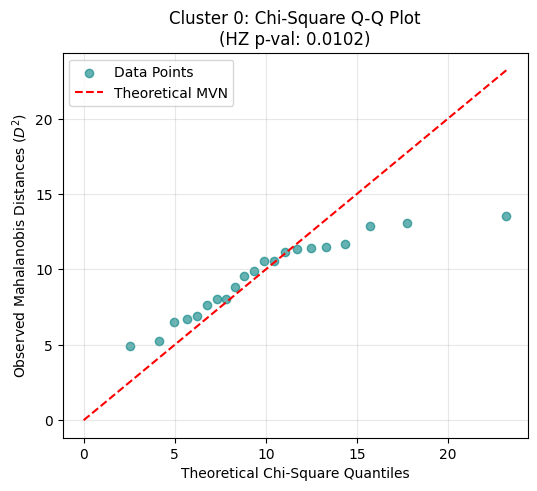


Analyzing Cluster 1 (n=55)


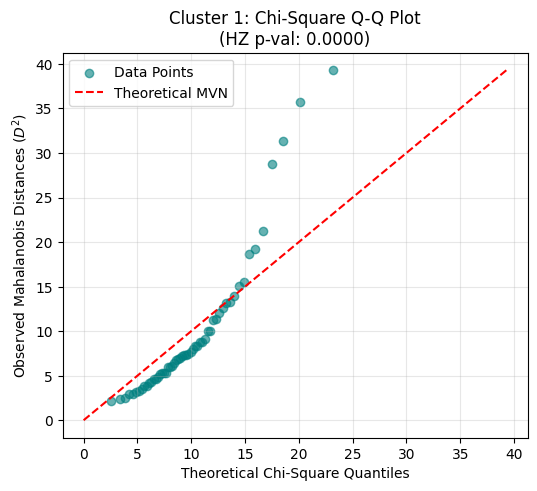

   Cluster  Samples    HZ_P-Value  Is_Normal
0        0       21  1.022283e-02      False
1        1       55  9.993906e-47      False


In [4]:
normality_report = test_gmm_normality_assumptions(X_pca, y_groundtruth)
print(normality_report)

### Reduction to 3 Dimensions

In [5]:
# 2. Apply PCA (Retaining )
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance= {pca.explained_variance_ratio_.sum()} \n")

Explained variance= 0.4430069228041906 



In [6]:
results_df = evaluate_imputers(X_pca, y_experts, y_groundtruth)
results_df.to_csv("results\\real_example\\3_d\\3d_metrics_results.csv")

# # Display a quick summary
results_df

,Accuracy,Recall_Class_1,Precision_Class_1,F1_Class_1,Pi_Diff_Class_1
Imputer,,,,,
Mode Imputer,0.763158,0.945455,0.776119,0.852459,0.071770
KNN Imputer (k=5),0.802632,0.927273,0.822581,0.871795,0.092105
Random Forest Imputer,0.736842,0.872727,0.786885,0.827586,0.078947
EM-GMM Imputer,0.750000,0.800000,0.846154,0.822430,0.017227


--- Multivariate Normality Diagnostic ---

Analyzing Cluster 0 (n=21)


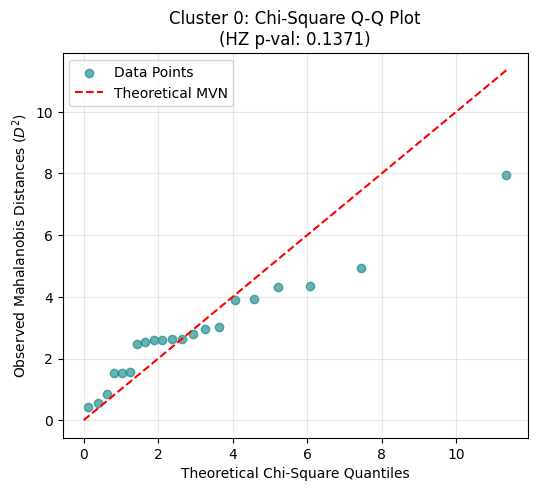


Analyzing Cluster 1 (n=55)


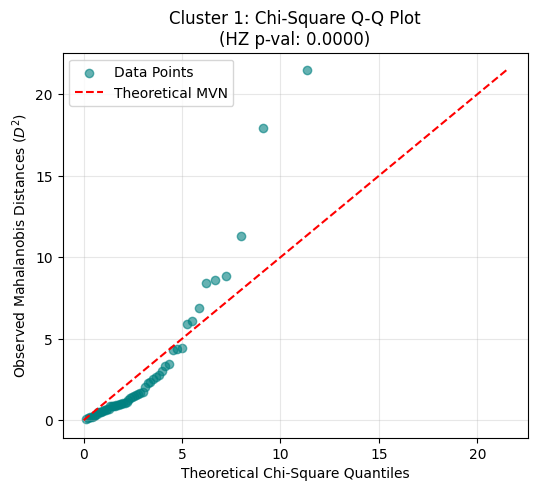

   Cluster  Samples    HZ_P-Value  Is_Normal
0        0       21  1.371310e-01       True
1        1       55  2.971381e-12      False


In [7]:

normality_report = test_gmm_normality_assumptions(X_pca, y_groundtruth)
print(normality_report)